In [30]:
import PriceRatioExperiment as PRE

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import random

import time

In [31]:
N = 100 # Number of agents

T = 1_000 # Length of Simulation

Mmax = 100 # Max possible money per agent
theta = 0.1 # Proportional change of prices in market
epsilon = 0.005 # Proportion of randomizing prices for agent
max_tries = 100 # Max number of market attempts

# Define Productivity Coefficients (Direct Labor Coefficients)
l1 = 0.9
l2 = 0.5

# Define the desired consumption rate
c1 = 1.0
c2 = 1.0

# The macro-economic condition must be satisfied
# l1*c1 + l2*c2 <= 1.0
print(l1*c1 + l2*c2)



1.4


In [32]:
# Inititialize Market Simulation
sim = PRE.PriceRatioExperiment(N, l1, l2, c1, c2, Mmax=Mmax, theta=theta, epsilon=epsilon, max_tries=max_tries, initial_money='uniform')

In [33]:
sim.N1, sim.N2

(90, 10)

In [34]:
#sim.scda.agent_Mdata

In [35]:
start_ = time.time()
Me_df, Qe_df, ntries_df, p_df, Magent_df = sim.run_experiment(T)
end_ = time.time()

In [36]:
lapse = end_ - start_
print(lapse/N)

0.13689908981323243


In [37]:
sim.scda.agent_data.shape

(100, 3, 2)

Text(0, 0.5, 'Market Attempts')

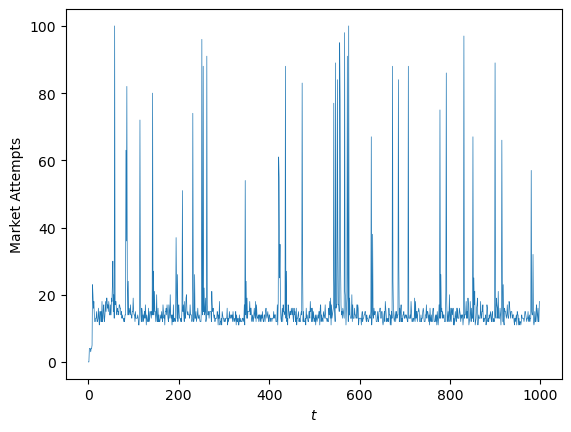

In [38]:
f, ax = plt.subplots()
ax.plot(ntries_df, lw=0.5)
ax.set_xlabel('$t$')
ax.set_ylabel('Market Attempts')

Text(0, 0.5, 'Price')

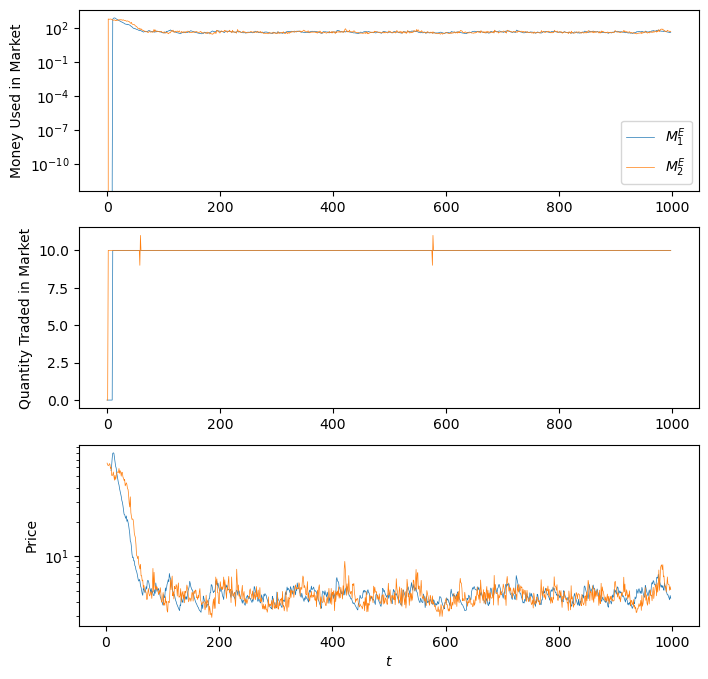

In [39]:
f, ax = plt.subplots(3,1, figsize=(8,8))
for i in range(2):
    ax[0].plot(Me_df[:,i], label=f'$M^E_{i+1}$', lw=0.5)
    ax[1].plot(Qe_df[:,i], label=f'%Q^E_{i+1}$', lw=0.5)
ax[2].plot(p_df, label=f'$p_{i+1}$', lw=0.5)
    
    
ax[0].legend()
ax[0].set_yscale('log')
ax[2].set_yscale('log')
ax[2].set_xlabel('$t$')
ax[0].set_ylabel('Money Used in Market')
ax[1].set_ylabel('Quantity Traded in Market')
ax[2].set_ylabel('Price')

In [40]:
sim.scda.agent_Mdata

array([3.77909417e+00, 4.21013407e+00, 8.99719954e+00, 5.80289435e+00,
       6.70900454e+00, 2.03412565e+00, 2.58062263e+00, 2.67183809e+00,
       2.25463984e+00, 6.51833296e+00, 4.85374407e+00, 5.06249913e+00,
       1.40255896e+00, 6.47329110e+00, 3.20211272e+00, 5.13810133e+00,
       7.71467032e+00, 2.04216476e+00, 1.14032318e+00, 4.77839557e+00,
       1.39444034e+00, 3.19732332e+00, 3.59236812e+00, 2.27955240e+00,
       5.48671269e+00, 3.82762351e+00, 3.28447257e+00, 7.85905960e+00,
       3.07795121e+00, 2.06737493e+00, 2.47536693e+00, 2.86962921e+00,
       9.76792983e+00, 2.92484673e+00, 3.26907662e+00, 2.57898495e+00,
       1.18375529e+00, 4.15020767e+00, 4.49653936e+00, 4.38618086e+00,
       1.28060194e+01, 3.59642615e+00, 1.93980650e+00, 1.27294975e+00,
       1.35119437e+01, 2.10999096e+00, 6.85825423e+00, 3.95313245e+00,
       5.38832521e+00, 3.58359087e+00, 3.27899383e+00, 5.17882695e+00,
       2.39409356e+00, 1.05354770e+01, 1.72504773e+00, 1.76782467e+00,
      

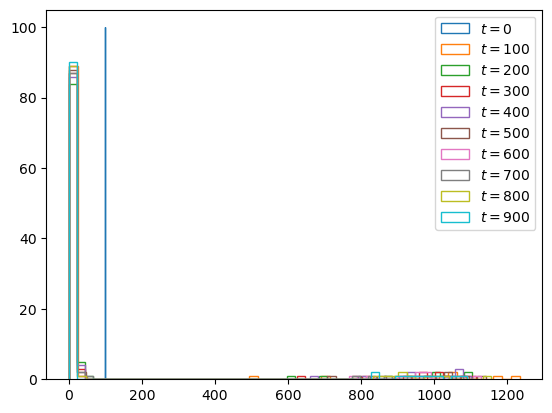

In [41]:
f, ax = plt.subplots()

for t in np.arange(0, T, 100):
    ax.hist(Magent_df[t], histtype='step', bins=50, label=f'$t={t}$')
ax.legend()

In [42]:
#Magent_df[10:].mean(axis=0)

In [43]:
Magent_df[10:].mean(axis=0)

array([   6.47517503,    5.19494356,    6.27113784,    6.85722388,
          5.41899888,    7.12642399,    5.96039945,    6.27553319,
          7.3807763 ,    5.04099821,    5.01372588,    6.40162533,
          6.72827887,    7.11619457,    5.9521279 ,    8.0928314 ,
          6.86038484,    4.90617987,    6.67494106,    6.22653084,
          5.47395688,    6.22634975,    6.45175865,    5.81635294,
          5.47333784,    7.77953377,    6.53459946,    5.79158554,
          4.56009138,    5.53685045,    5.73199991,    5.89138279,
          6.40527511,    5.73350546,    7.36018174,    7.12658015,
          6.49014068,    5.77408562,    8.41605157,    6.27386145,
          6.27968358,    6.25183754,    6.07229563,    5.63755384,
          6.16426753,    5.42139224,    6.28350657,    5.18025074,
          5.64112936,    4.84008025,    6.82654966,    6.9275848 ,
          7.17970422,    5.71752671,    6.78824121,    4.59892917,
          6.01450888,    5.54677457,    6.58961105,    4.89816

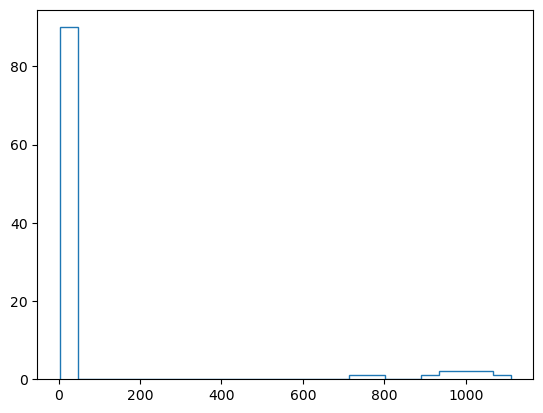

In [44]:
plt.hist(Magent_df[100:].mean(axis=0), histtype='step', bins=25)
plt.show()

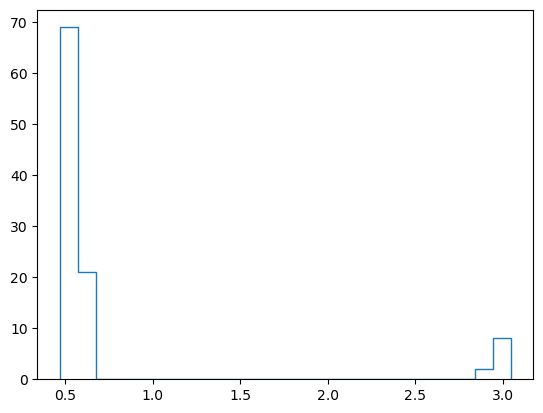

In [45]:
plt.hist(np.log10(Magent_df[100:]).mean(axis=0), histtype='step', bins=25)
plt.show()

In [ ]:
assert False

In [ ]:
N = 100
num = 11

prod_values = np.logspace(-1, 1, num)
labor_coeffs = 1.0/prod_values

In [ ]:
T = 500

n = len(labor_coeffs)
n = n*n

l_ratio_df = []
p_ratio_df = []
p_ratio_std_df = []
c1_df = []

for l1 in labor_coeffs:
    
    print(l1)
    
    for l2 in labor_coeffs:
        
        try:
    
            c1 = np.random.uniform(0, 1.0/l1)
            c2 = 1.0/l2*(1.0 - l1*c1)

            pre = PRE.PriceRatioExperiment(N, l1, l2, c1, c2)
            print(l1, l2)
            print(c1, c2)
            print(pre.N1, pre.N2)
            print(l1*c1 + l2*c2)
            print()

            Me_df, Qe_df, ntries_df, p_df = pre.run_experiment(T)

            p_ratio     = np.nanmean(p_df[:,0]/p_df[:,1])
            p_ratio_std = np.nanstd(p_df[:,0]/p_df[:,1])

            
        except:
            
            print('Fail for')
            print(l1, l2)
            print()
            
            p_ratio = np.nan
            p_ratio_std = np.nan
        
        l_ratio_df.append(l1/l2)
        p_ratio_df.append(p_ratio)
        p_ratio_std_df.append(p_ratio_std)
        c1_df.append(c1)

        
        
        

In [ ]:
plt.scatter(l_ratio_df, p_ratio_df, s = 0.5, c='k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Productivity Ratios ($l_1/l_2$)')
plt.ylabel('Price Ratios ($p_1/p_2$)')

x = np.logspace(-3,3,10)
plt.plot(x,x, c='k', lw=0.1)
plt.xlim(5e-3, 2e2)
plt.ylim(5e-3, 2e2)

In [ ]:
plt.scatter(p_ratio_df, p_ratio_std_df, c='k', s=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Price Ratios ($p_1/p_2$)')
plt.ylabel('Price Ratio Standard Deviations')

In [ ]:
plt.scatter(p_ratio_df, c1_df, c='k', s=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Price Ratios ($p_1/p_2$)')
plt.ylabel(r'$\bar{c}_1$')